In [1]:
import numpy as np
from numpy.typing import NDArray
from typing import Callable,Tuple,List,Optional
import matplotlib.pyplot as plt
from tqdm import tqdm


In [2]:

def gaus2d_pdf(x, y, mx, my, sx, sy):
    """
    Calculates the 2D Gaussian probability density function value at a given point.
    """
    return 1. / (2. * np.pi * sx * sy) * np.exp(-((x - mx)**2. / (2. * sx**2.) + (y - my)**2. / (2. * sy**2.)))

# Create a grid of coordinates
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y) # Creates 2D variables from 1D arrays

# Example usage with center (mx, my) = (0, 0) and spreads (sx, sy) = (1, 1)
z = gaus2d_pdf(X, Y, mx=0, my=0, sx=1, sy=1)

def periodic_distance_sq(x, y, xc, yc, Nx, Ny):
    dx = (x - xc + Nx/2) % Nx - Nx/2
    dy = (y - yc + Ny/2) % Ny - Ny/2
    return dx*dx + dy*dy


In [3]:

class Particle:
    def __init__(self, i, x, y, theta, radius) -> None:
        self.id = i
        # wrapped (for simulation)
        self.x = x
        self.y = y
        # unwrapped (for tracking)
        self.x_unwrapped = x
        self.y_unwrapped = y
        self.theta = theta
        self.radius = radius
        self.v = 5.0

def populate_is_occupied(radius, xc, yc, id, is_occupied: NDArray,
                        collisions: List[Tuple[int, int]]):
    Ny, Nx = is_occupied.shape
    xc_int = int(xc)
    yc_int = int(yc)
    xa = xc_int - int(radius)
    xb = xc_int + int(radius) + 1
    ya = yc_int - int(radius)
    yb = yc_int + int(radius) + 1
    for x in range(xa, xb):
        for y in range(ya, yb):
            distance2 = periodic_distance_sq(x, y, xc, yc, Nx, Ny)
            if distance2 <= radius*radius:
                xp = x % Nx
                yp = y % Ny
                if is_occupied[yp, xp] == -1:
                    is_occupied[yp, xp] = id
                else:
                    collisions.append((id, is_occupied[yp, xp]))

def move(particle: Particle, Nx: int, Ny: int, chemA: NDArray, chemB: NDArray) -> None:
    dx = particle.v * np.cos(particle.theta)
    dy = particle.v * np.sin(particle.theta)
    particle.x = (particle.x + dx) % Nx
    particle.y = (particle.y + dy) % Ny
    particle.x_unwrapped += dx
    particle.y_unwrapped += dy

def deposit_chemA(particles: List[Particle], chemA: NDArray, is_occupied: NDArray):
    Ny, Nx = chemA.shape
    chemA[:] = 1
    for particle in particles:
        xc = particle.x
        yc = particle.y
        r = particle.radius
        xc_int = int(xc)
        yc_int = int(yc)
        for x in range(xc_int - int(r), xc_int + int(r) + 1):
            for y in range(yc_int - int(r), yc_int + int(r) + 1):
                dist2 = periodic_distance_sq(x, y, xc, yc, Nx, Ny)
                if dist2 <= r*r:
                    xp = x % Nx
                    yp = y % Ny
                    chemA[yp, xp] = 0

def deposit_chemB(particles: List[Particle], chemB: NDArray, strength=1.0):
    Ny, Nx = chemB.shape
    for particle in particles:
        xc = particle.x
        yc = particle.y
        r = particle.radius
        xc_int = int(xc)
        yc_int = int(yc)
        for x in range(xc_int - int(r), xc_int + int(r) + 1):
            for y in range(yc_int - int(r), yc_int + int(r) + 1):
                dist2 = periodic_distance_sq(x, y, xc, yc, Nx, Ny)
                if dist2 <= r*r:
                    xp = x % Nx
                    yp = y % Ny
                    chemB[yp, xp] += strength

def laplacian(field: NDArray) -> NDArray:
    lap_field = np.full(shape=field.shape, fill_value=np.nan)
    Ny, Nx = field.shape
    for y in range(Ny):
        for x in range(Nx):
            term = (field[(y+1)%Ny, x] + field[(y-1)%Ny, x] +
                    field[y, (x+1)%Nx] + field[y, (x-1)%Nx] -
                    4 * field[y, x])
            lap_field[y, x] = term
    return lap_field

def gradient(field: NDArray) -> Tuple[NDArray, NDArray]:
    Ny, Nx = field.shape
    grad_x = np.full(field.shape, np.nan)
    grad_y = np.full(field.shape, np.nan)
    for y in range(Ny):
        for x in range(Nx):
            grad_x[y, x] = (field[y, (x+1)%Nx] - field[y, (x-1)%Nx]) * 0.5
            grad_y[y, x] = (field[(y+1)%Ny, x] - field[(y-1)%Ny, x]) * 0.5
    return grad_x, grad_y

def init_gaussian(chemB, x0, y0, sigma=10.0, amplitude=1.0):
    Ny, Nx = chemB.shape
    for y in range(Ny):
        for x in range(Nx):
            dx = x - x0
            dy = y - y0
            chemB[y, x] += amplitude * np.exp(-(dx*dx + dy*dy) / (2*sigma*sigma))

def make_circular_kernel(R: float, dx: float = 1.0) -> NDArray:
    radius_cells = max(1, int(np.ceil(R / dx)))
    offsets = np.arange(-radius_cells, radius_cells + 1, dtype=float)
    yy, xx = np.meshgrid(offsets, offsets, indexing="ij")
    footprint = ((xx * dx)**2 + (yy * dx)**2) <= R * R
    kernel = footprint.astype(np.float64)
    kernel_sum = kernel.sum()
    if kernel_sum == 0:
        kernel[radius_cells, radius_cells] = 1.0
        kernel_sum = 1.0
    return kernel / kernel_sum

def local_field_avg(chem: NDArray, R: float, dx: float = 1.0, kernel: Optional[NDArray] = None) -> NDArray:
    """Compute circular neighborhood averages via FFT-based convolution."""
    if kernel is None:
        kernel = make_circular_kernel(R, dx)
    kernel_ft = np.fft.fft2(kernel, s=chem.shape)
    chem_ft = np.fft.fft2(chem)
    avg = np.fft.ifft2(chem_ft * kernel_ft).real
    return avg.astype(chem.dtype, copy=False)

def update_theta(particle: Particle,
                gradAx, gradAy,
                gradBx, gradBy,
                chi=1.0, dt=0.1):
    Ny, Nx = gradAx.shape
    i = int(particle.y) % Ny
    j = int(particle.x) % Nx
    fx = gradAx[i, j] - gradBx[i, j]
    fy = gradAy[i, j] - gradBy[i, j]
    if fx*fx + fy*fy < 1e-8:
        theta_f = particle.theta + 0.1*np.random.randn()
    else:
        theta_f = np.arctan2(fy, fx)
    particle.theta += dt * chi * np.sin(theta_f - particle.theta)



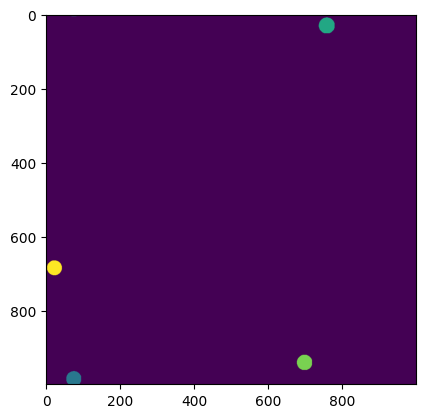

In [4]:
L = 10
BASE_NX = 100
BASE_NY = 100 
Nx = L*BASE_NX
Ny = L*BASE_NY
num_particles = 4
num_steps = 20

is_occupied  = np.full((Ny,Nx),fill_value=-1,dtype=np.int16)
chemA = np.full((Ny,Nx),fill_value=0.0,dtype=np.float32)
chemB = np.full((Ny,Nx),fill_value=0.0,dtype=np.float32)

particles = []
collisions = []
for i in range(1,num_particles+1):
    x =  Nx *np.random.rand()
    y =  Ny *np.random.rand()
    theta = 2*np.pi* np.random.rand()
    radius = 20.0 + 5.*np.random.rand()
    particles.append(Particle(i,x,y,theta,radius))


deposit_chemA(particles=particles,chemA=chemA,is_occupied=is_occupied)
deposit_chemB(particles=particles,chemB=chemB)

for particle in particles:
    populate_is_occupied(radius=particle.radius,xc=particle.x,yc=particle.y,
                        id=particle.id,is_occupied=is_occupied,collisions=collisions)
    
plt.imshow(is_occupied)


In [5]:
# --- field computation (ONCE per step) ---
avgA = local_field_avg(chemA, R=10)
avgB = local_field_avg(chemB, R=10)

dAdx, dAdy = gradient(avgA)
dBdx, dBdy = gradient(avgB)

# --- particle update ---
for particle in particles:
    update_theta(particle, dAdx, dAdy, dBdx, dBdy)
    move(particle, Nx, Ny, chemA, chemB)


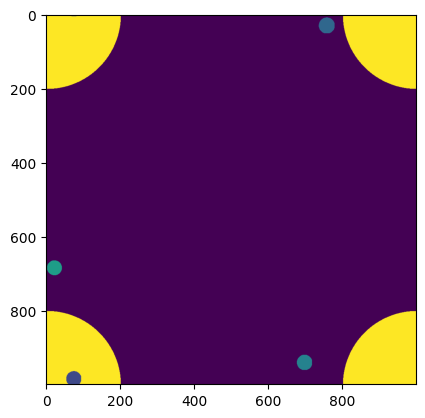

In [6]:
populate_is_occupied(radius=200,xc=2,yc=2,
                        id=8,is_occupied=is_occupied,collisions=collisions)
plt.imshow(is_occupied)


In [ ]:

positions = np.full(shape=(num_steps, num_particles, 2),fill_value=np.nan)

for i in tqdm(range(num_steps)):
    is_occupied.fill(-1)
    collisions.clear()
    
    avgA = local_field_avg(chemA, R=10)
    avgB = local_field_avg(chemB, R=10)
    print(avgA)
    dAdx, dAdy = gradient(avgA)
    dBdx, dBdy = gradient(avgB)

# --- particle update ---
    for particle in particles:
        populate_is_occupied(radius=particle.radius,xc=particle.x,yc=particle.y,
                                id=particle.id,is_occupied=is_occupied,collisions=collisions)
        update_theta(particle, dAdx, dAdy, dBdx, dBdy)
        move(particle, Nx, Ny, chemA, chemB)
        positions[i,particle.id-1,0] = particle.x_unwrapped
        positions[i,particle.id-1,1] = particle.y_unwrapped
        print(particle.x,particle.y)
        


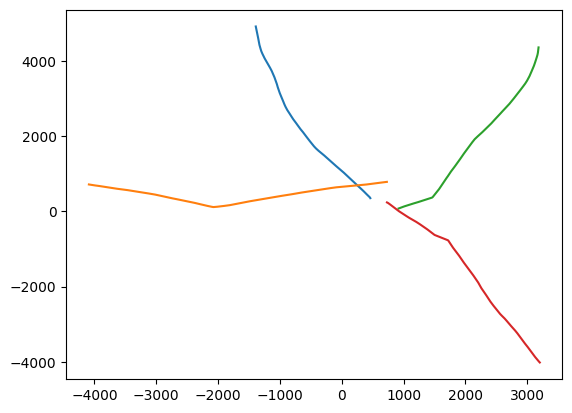

In [13]:

# deposit_chemB(particles=particles,chemB=chemB)
positions = np.load('/work/vicsek_model/positions_data.npy')
for i in range(num_particles):
    plt.plot(positions[:,i,0],positions[:,i,1])

In [26]:
positions[:,0,:].shape

(1000, 2)

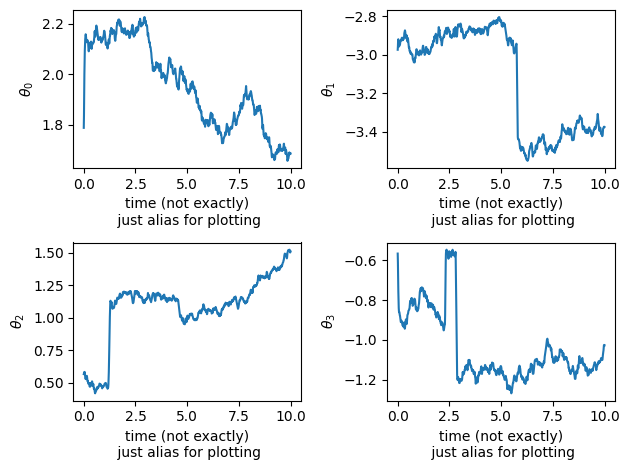

In [38]:

def cal_velocity(arr: NDArray, dt: float = 1.0) -> NDArray:

    x = arr[:, 0]
    y = arr[:, 1]

    v = np.zeros_like(arr)

    # central difference (interior points)
    v[1:-1, 0] = (x[2:] - x[:-2]) / (2 * dt)
    v[1:-1, 1] = (y[2:] - y[:-2]) / (2 * dt)

    # forward difference (first point)
    v[0, 0] = (x[1] - x[0]) / dt
    v[0, 1] = (y[1] - y[0]) / dt

    # backward difference (last point)
    v[-1, 0] = (x[-1] - x[-2]) / dt
    v[-1, 1] = (y[-1] - y[-2]) / dt

    return v

fig,ax = plt.subplots(2,2)
ax = ax.flatten()
for i in range(num_particles):
    v = cal_velocity(arr=positions[:,i,:])
    theta = np.arctan2(v[:,1],v[:,0])
    theta = np.unwrap(theta)
    ax[i].plot(np.linspace(0,10,theta.shape[0]),theta)
    ax[i].set_xlabel('time (not exactly)\n just alias for plotting')
    ax[i].set_ylabel(rf'$\theta_{i}$')


fig.tight_layout()


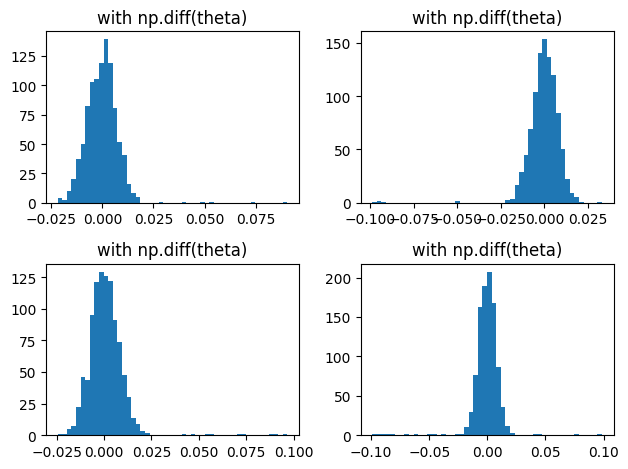

In [40]:

fig,ax = plt.subplots(2,2)
ax = ax.flatten()
for i in range(num_particles):
    v = cal_velocity(arr=positions[:,i,:])
    theta = np.arctan2(v[:,1],v[:,0])
    theta = np.unwrap(theta)

    ax[i].set_title('with np.diff(theta)')
    # ax[i].plot(np.diff(theta))
    *_,plot= ax[i].hist(np.diff(theta), bins=50)
fig.tight_layout()